In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from scipy.ndimage import convolve
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

from data_handling import load_dataset, save_dataset
from preprocessing_utils import one_hot_encode, adaptive_robust_binning, PREPROCESSED_DIR

# Iris Dataset Preprocessing
Apply percentile encoding with optimal bin counts determined through mutual information with target variable to the Iris dataset and save both original and transformed versions.

In [2]:
X_iris, y_iris, cat_features_iris, class_mapping_iris = load_dataset('Iris')

if not isinstance(X_iris, pd.DataFrame):
    X_iris = pd.DataFrame(X_iris, columns=[f"feature_{i}" for i in range(X_iris.shape[1])])

save_dataset('Iris', X_iris, y_iris, cat_features_iris, class_mapping_iris, PREPROCESSED_DIR,'original')

description = X_iris.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'Iris_original_description.csv')
description.to_csv(description_path)

Loaded Iris dataset from cache (150 samples, 4 features)
Saved Iris_original dataset (150 samples, 4 features)


In [3]:
num_cols = X_iris.columns.tolist()

X_iris_binned = adaptive_robust_binning(
    X_iris,
    num_cols,
    y=y_iris,
    min_adaptive_bins=5,
    max_adaptive_bins=10
)

save_dataset('Iris', X_iris_binned, y_iris, cat_features_iris, class_mapping_iris, PREPROCESSED_DIR,'binned')

description = X_iris_binned.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'Iris_binned_description.csv')
description.to_csv(description_path)

Saved Iris_binned dataset (150 samples, 4 features)


# Wine Dataset Preprocessing
Preprocess the Wine same as Iris Dataset

In [4]:
X_wine, y_wine, cat_features_wine, class_mapping_wine = load_dataset('Wine')

if not isinstance(X_wine, pd.DataFrame):
    X_wine = pd.DataFrame(X_wine, columns=[f"feature_{i}" for i in range(X_wine.shape[1])])

save_dataset('Wine', X_wine, y_wine, cat_features_wine, class_mapping_wine, PREPROCESSED_DIR, 'original')

description = X_wine.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'Wine_original_description.csv')
description.to_csv(description_path)

Loaded Wine dataset from cache (6497 samples, 11 features)
Saved Wine_original dataset (6497 samples, 11 features)


In [5]:
num_cols = X_wine.columns.tolist()

X_wine_binned = adaptive_robust_binning(
    X_wine,
    num_cols,
    y=y_wine,
    min_adaptive_bins=8,
    max_adaptive_bins=15
)

save_dataset('Wine', X_wine_binned, y_wine, cat_features_wine, class_mapping_wine, PREPROCESSED_DIR, 'binned')

description_binned = X_wine_binned.describe(include='all')
description_binned_path = os.path.join(PREPROCESSED_DIR, 'Wine_binned_description.csv')
description_binned.to_csv(description_binned_path)

Saved Wine_binned dataset (6497 samples, 11 features)


# Adult Census Dataset Preprocessing
Preprocess the Adult Census dataset through feature selection, outlier handling, missing value treatment, and creating multiple versions: basic, binned, and category-reduced variants.

In [6]:
X_adult, y_adult, cat_features_adult, class_mapping_adult = load_dataset('Adult_Census')

if not isinstance(X_adult, pd.DataFrame):
    X_adult = pd.DataFrame(X_adult, columns=[f"feature_{i}" for i in range(X_adult.shape[1])])

X_adult.describe(include='all')

Loaded Adult_Census dataset from cache (48842 samples, 14 features)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN


In [7]:
if 'fnlwgt' in X_adult.columns:
    X_adult = X_adult.drop(columns=['fnlwgt'])

if 'education' in X_adult.columns and 'education-num' in X_adult.columns:
    X_adult = X_adult.drop(columns=['education'])
    cat_features_adult = [f for f in cat_features_adult if f != 'education']

y_adult_series = pd.Series(y_adult)
y_adult_series = y_adult_series.map(lambda x: '<=50K' if x in ['<=50K', '<=50K.'] else '>50K')
y_adult_int = y_adult_series.map({'<=50K': 0, '>50K': 1})
class_mapping_adult = {0: '<=50K', 1: '>50K'}
y_adult = y_adult_int.values

num_features_adult = [col for col in X_adult.columns if col not in cat_features_adult]

X_adult_clean = X_adult.dropna()
y_adult_clean = y_adult_int.loc[X_adult_clean.index].values

X_adult_super_clean = X_adult_clean.copy()

for col in cat_features_adult:
    if col not in X_adult_super_clean.columns:
        continue
    if col == 'workclass':
        govt_categories = ['Federal-gov', 'State-gov', 'Local-gov']
        private_categories = ['Private']
        self_emp_categories = ['Self-emp-inc', 'Self-emp-not-inc']
        other_categories = ['Without-pay', 'Never-worked', '?']

        mapping = {}
        for cat in govt_categories:
            mapping[cat] = 'Government'
        for cat in private_categories:
            mapping[cat] = 'Private'
        for cat in self_emp_categories:
            mapping[cat] = 'Self-employed'
        for cat in other_categories:
            mapping[cat] = 'Other'
        X_adult_super_clean[col] = X_adult_super_clean[col].map(lambda x: mapping.get(x, 'Other'))

    elif col == 'education':
        if 'education-num' in X_adult_super_clean.columns:
            high_school_or_less = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad']
            some_college = ['Some-college', 'Assoc-voc', 'Assoc-acdm']
            college_grad = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

            mapping = {}
            for cat in high_school_or_less:
                mapping[cat] = 'High-School-or-Less'
            for cat in some_college:
                mapping[cat] = 'Some-College'
            for cat in college_grad:
                mapping[cat] = 'College-Graduate'

            X_adult_super_clean[col] = X_adult_super_clean[col].map(lambda x: mapping.get(x, 'Unknown'))

    elif col == 'native-country':
        north_america = ['United-States', 'Canada', 'Mexico', 'Puerto-Rico', 'Honduras', 'Jamaica', 'Cuba', 'Dominican-Republic', 'Haiti', 'Guatemala', 'El-Salvador', 'Nicaragua', 'Outlying-US(Guam-USVI-etc)', 'Trinadad&Tobago']
        europe = ['England', 'Germany', 'Italy', 'Poland', 'Portugal', 'France', 'Greece', 'Ireland', 'Hungary', 'Scotland','Yugoslavia', 'Holand-Netherlands']
        asia = ['China', 'Japan', 'India', 'Iran', 'Philippines', 'Vietnam', 'Taiwan', 'Hong', 'Cambodia', 'Thailand', 'Laos']
        other = ['South', 'Ecuador', 'Columbia', 'Peru', '?']

        mapping = {}
        for cat in north_america:
            mapping[cat] = 'North-America'
        for cat in europe:
            mapping[cat] = 'Europe'
        for cat in asia:
            mapping[cat] = 'Asia'
        for cat in other:
            mapping[cat] = 'Other'
        X_adult_super_clean[col] = X_adult_super_clean[col].map(lambda x: mapping.get(x, 'Other'))

    else:
        value_counts = X_adult_super_clean[col].value_counts(normalize=True)
        rare_categories = value_counts[value_counts < 0.01].index.tolist()

        if rare_categories:
            X_adult_super_clean[col] = X_adult_super_clean[col].apply(lambda x: 'Other' if x in rare_categories else x)

# 1. Basic dataset with one-hot encoding

In [8]:
X_adult_basic_clean = one_hot_encode(X_adult_clean, cat_features_adult)
save_dataset('AdultCensus', X_adult_basic_clean, y_adult_clean, None, class_mapping_adult, PREPROCESSED_DIR, 'basic_clean')

description = X_adult_basic_clean.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'AdultCensus_basic_clean_description.csv')
description.to_csv(description_path)

Saved AdultCensus_basic_clean dataset (47621 samples, 91 features)


# 2. Binned dataset with one-hot encoding

In [9]:
X_adult_bin_clean = adaptive_robust_binning(
    X_adult_clean,
    num_features_adult,
    y=y_adult_clean,
    min_adaptive_bins=10,
    max_adaptive_bins=20,
)

X_adult_binned_clean = one_hot_encode(X_adult_bin_clean, cat_features_adult)
save_dataset('AdultCensus', X_adult_binned_clean, y_adult_clean, None, class_mapping_adult, PREPROCESSED_DIR, 'binned_clean')

description = X_adult_binned_clean.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'AdultCensus_binned_clean_description.csv')
description.to_csv(description_path)

Saved AdultCensus_binned_clean dataset (47621 samples, 91 features)


# 3. Reduced dataset with supercategories

In [10]:
X_adult_super_bin_clean = adaptive_robust_binning(
    X_adult_super_clean,
    num_features_adult,
    y=y_adult_clean,
    min_adaptive_bins=10,
    max_adaptive_bins=20
)

X_adult_reduced_clean = one_hot_encode(X_adult_super_bin_clean, cat_features_adult)
save_dataset('AdultCensus', X_adult_reduced_clean, y_adult_clean, None, class_mapping_adult, PREPROCESSED_DIR, 'reduced_clean')

description = X_adult_reduced_clean.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'AdultCensus_binned_reduced_description.csv')
description.to_csv(description_path)

Saved AdultCensus_reduced_clean dataset (47621 samples, 46 features)


# Bank Marketing Dataset Preprocessing
Preprocess the Bank Marketing dataset by removing leaking features, engineering new features, and implementing both imputation and row removal strategies for missing values.

In [11]:
X_bank, y_bank, cat_features_bank, class_mapping_bank = load_dataset('Bank_Marketing')

if not isinstance(X_bank, pd.DataFrame):
    X_bank = pd.DataFrame(X_bank, columns=[f"feature_{i}" for i in range(X_bank.shape[1])])

X_bank.describe(include='all')

Loaded Bank_Marketing dataset from cache (45211 samples, 16 features)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
count,45211.000000,44923,45211,43354,45211,45211.000000,45211,45211,32191,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,8252
unique,NaN,11,3,3,2,NaN,2,2,2,NaN,12,NaN,NaN,NaN,NaN,3
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,failure
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,4901
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN


In [12]:
columns_to_remove = []

if 'duration' in X_bank.columns:
    columns_to_remove.append('duration')

if 'pdays' in X_bank.columns:
    columns_to_remove.append('pdays')

for col in ['day_of_week', 'month', 'contact']:
    if col in X_bank.columns:
        columns_to_remove.append(col)
        if col in cat_features_bank:
            cat_features_bank = [f for f in cat_features_bank if f != col]

X_bank = X_bank.drop(columns=columns_to_remove)

y_bank_series = pd.Series(y_bank)
y_bank_int = y_bank_series.map({'no': 0, 'yes': 1})
class_mapping_bank = {0: 'no', 1: 'yes'}
y_bank = y_bank_int.values

num_features_bank = [col for col in X_bank.columns if col not in cat_features_bank]

if 'previous' in X_bank.columns:
    X_bank['previously_contacted'] = (X_bank['previous'] > 0).astype(int)

if 'poutcome' in X_bank.columns:
    X_bank['poutcome'] = X_bank['poutcome'].fillna("nonexistent")

X_bank_clean = X_bank.dropna()
y_bank_clean = y_bank_int.loc[X_bank_clean.index].values

X_bank_imputed = X_bank.copy()

for col in cat_features_bank:
    if col in X_bank.columns and X_bank[col].isna().any():
        most_frequent = X_bank[col].mode()[0]
        X_bank_imputed[col] = X_bank_imputed[col].fillna(most_frequent)

for col in num_features_bank:
    if col in X_bank.columns and X_bank[col].isna().any():
        median_value = X_bank[col].median()
        X_bank_imputed[col] = X_bank_imputed[col].fillna(median_value)

# 1. Basic dataset with one-hot encoding and imputation

In [13]:
X_bank_basic_imputed = one_hot_encode(X_bank_imputed, cat_features_bank)
save_dataset('BankMarketing', X_bank_basic_imputed, y_bank, None, class_mapping_bank, PREPROCESSED_DIR, 'basic_imputed')

description = X_bank_basic_imputed.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'BankMarketing_basic_imputed_description.csv')
description.to_csv(description_path)

Saved BankMarketing_basic_imputed dataset (45211 samples, 32 features)


# 2. Basic dataset with one-hot encoding and row deletion

In [14]:
X_bank_basic_clean = one_hot_encode(X_bank_clean, cat_features_bank)
save_dataset('BankMarketing', X_bank_basic_clean, y_bank_clean, None, class_mapping_bank, PREPROCESSED_DIR, 'basic_clean')

description = X_bank_basic_clean.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'BankMarketing_basic_clean_description.csv')
description.to_csv(description_path)

Saved BankMarketing_basic_clean dataset (43193 samples, 32 features)


# 3. Binned dataset with one-hot encoding and imputation

In [15]:
num_features_bank_imputed = [col for col in X_bank_imputed.columns if col not in cat_features_bank]

X_bank_bin_imputed = adaptive_robust_binning(
    X_bank_imputed,
    num_features_bank_imputed,
    y=y_bank,
    min_adaptive_bins=10,
    max_adaptive_bins=15,
)

X_bank_binned_imputed = one_hot_encode(X_bank_bin_imputed, cat_features_bank)
save_dataset('BankMarketing', X_bank_binned_imputed, y_bank, None, class_mapping_bank, PREPROCESSED_DIR, 'binned_imputed')

description = X_bank_binned_imputed.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'BankMarketing_binned_imputed_description.csv')
description.to_csv(description_path)

Saved BankMarketing_binned_imputed dataset (45211 samples, 32 features)


# 4. Binned dataset with one-hot encoding and row deletion

In [16]:
num_features_bank_clean = [col for col in X_bank_clean.columns if col not in cat_features_bank]

X_bank_bin_clean = adaptive_robust_binning(
    X_bank_clean,
    num_features_bank_clean,
    y=y_bank_clean,
    min_adaptive_bins=10,
    max_adaptive_bins=15,
)

X_bank_binned_clean = one_hot_encode(X_bank_bin_clean, cat_features_bank)
save_dataset('BankMarketing', X_bank_binned_clean, y_bank_clean, None, class_mapping_bank, PREPROCESSED_DIR, 'binned_clean')

description = X_bank_binned_clean.describe(include='all')
description_path = os.path.join(PREPROCESSED_DIR, 'BankMarketing_binned_clean_description.csv')
description.to_csv(description_path)

Saved BankMarketing_binned_clean dataset (43193 samples, 32 features)


# MNIST Dataset Preprocessing
Implement dimensionality reduction and feature engineering for the MNIST dataset including variance thresholding, convolution filters, region-based features, and distance metrics.
## Make 2 versions:
1. with filters and pixels
2. with only filters

In [17]:
X_mnist, y_mnist, cat_features_mnist, class_mapping_mnist = load_dataset('MNIST')

if not isinstance(X_mnist, pd.DataFrame):
    X_mnist = pd.DataFrame(X_mnist, columns=[f"pixel_{i}" for i in range(X_mnist.shape[1])])

X_mnist.describe()

Loaded MNIST dataset from cache (70000 samples, 784 features)


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197414,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.991206,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [18]:
def remove_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    df_reduced = df.drop(columns=to_drop)
    return df_reduced

def images_from_df(df, img_size=28):
    n_samples = df.shape[0]
    images = np.zeros((n_samples, img_size, img_size))

    for i in range(n_samples):
        pixel_values = df.iloc[i].values
        if len(pixel_values) < img_size*img_size:
            mask = np.zeros(img_size*img_size)
            kept_indices = [int(col.split('_')[1]) for col in df.columns]
            mask[kept_indices] = pixel_values
            pixel_values = mask

        images[i] = pixel_values.reshape(img_size, img_size)

    return images

def create_filters():
    filters = {}

    filters['horizontal'] = np.array([[-1, -1, -1], [2, 2, 2], [-1, -1, -1]])
    filters['vertical'] = np.array([[-1, 2, -1], [-1, 2, -1], [-1, 2, -1]])
    filters['diagonal1'] = np.array([[-1, -1, 2], [-1, 2, -1], [2, -1, -1]])
    filters['diagonal2'] = np.array([[2, -1, -1], [-1, 2, -1], [-1, -1, 2]])

    filters['smooth'] = np.ones((3, 3)) / 9
    filters['gaussian'] = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
    filters['sharpen'] = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    filters['emboss'] = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])

    return filters

def extract_filter_features(images):
    filters = create_filters()
    n_samples = images.shape[0]
    n_filters = len(filters)

    features = np.zeros((n_samples, n_filters * 5))

    for i in range(n_samples):
        img = images[i]
        feature_idx = 0

        for filter_name, filter_kernel in filters.items():
            filtered = convolve(img, filter_kernel)

            features[i, feature_idx] = filtered.mean()
            features[i, feature_idx+1] = filtered.std()
            features[i, feature_idx+2] = filtered.max()
            features[i, feature_idx+3] = np.percentile(filtered, 75)
            features[i, feature_idx+4] = np.sum(filtered > 0)

            feature_idx += 5

    return features

def extract_region_features(images, n_regions=4):
    n_samples = images.shape[0]
    img_size = images.shape[1]
    region_size = img_size // n_regions
    n_features = n_regions * n_regions * 4

    features = np.zeros((n_samples, n_features))

    for i in range(n_samples):
        img = images[i]
        feature_idx = 0

        for r_row in range(n_regions):
            for r_col in range(n_regions):
                r_start_row = r_row * region_size
                r_end_row = (r_row + 1) * region_size
                r_start_col = r_col * region_size
                r_end_col = (r_col + 1) * region_size

                region = img[r_start_row:r_end_row, r_start_col:r_end_col]

                features[i, feature_idx] = region.mean()
                features[i, feature_idx+1] = region.std()
                features[i, feature_idx+2] = region.max()
                features[i, feature_idx+3] = np.sum(region > 0) / region.size

                feature_idx += 4

    return features

def extract_distance_features(images):
    n_samples = images.shape[0]
    img_size = images.shape[1]
    center = img_size // 2
    features = np.zeros((n_samples, 8))

    for i in range(n_samples):
        img = images[i]

        if np.sum(img) == 0:
            com_row, com_col = center, center
        else:
            rows, cols = np.mgrid[:img_size, :img_size]
            com_row = np.average(rows, weights=img)
            com_col = np.average(cols, weights=img)

        features[i, 0] = np.sqrt((com_row - center)**2 + (com_col - center)**2)

        top_left = np.sum(img[:center, :center])
        top_right = np.sum(img[:center, center:])
        bottom_left = np.sum(img[center:, :center])
        bottom_right = np.sum(img[center:, center:])

        total_mass = top_left + top_right + bottom_left + bottom_right
        if total_mass > 0:
            features[i, 1] = top_left / total_mass
            features[i, 2] = top_right / total_mass
            features[i, 3] = bottom_left / total_mass
            features[i, 4] = bottom_right / total_mass

        h_symm = 1 - np.sum(np.abs(img - np.fliplr(img))) / (2 * np.sum(img) + 1e-10)
        v_symm = 1 - np.sum(np.abs(img - np.flipud(img))) / (2 * np.sum(img) + 1e-10)
        features[i, 5] = h_symm
        features[i, 6] = v_symm

        nonzero = img > 0
        if np.sum(nonzero) > 0:
            row_indices, col_indices = np.where(nonzero)
            height = row_indices.max() - row_indices.min() + 1
            width = col_indices.max() - col_indices.min() + 1
            features[i, 7] = width / (height + 1e-10)

    return features

In [19]:
print(f"Original dimensions: {X_mnist.shape}")

low_var_threshold = 0.01 * X_mnist.var().max()
selector = VarianceThreshold(threshold=low_var_threshold)
X_reduced = selector.fit_transform(X_mnist)
X_reduced_df = pd.DataFrame(X_reduced, columns=[f"pixel_{i}" for i in range(X_reduced.shape[1])])

print(f"After variance filtering: {X_reduced_df.shape}")

X_decorr = remove_correlated_features(X_reduced_df, threshold=0.95)
print(f"After correlation filtering: {X_decorr.shape}")

print("Extracting features from images...")

images = images_from_df(X_mnist)

filter_features = extract_filter_features(images)
print(f"Filter features shape: {filter_features.shape}")

region_features = extract_region_features(images, n_regions=4)
print(f"Region features shape: {region_features.shape}")

distance_features = extract_distance_features(images)
print(f"Distance features shape: {distance_features.shape}")

X_features = np.hstack([
    X_decorr.values,
    filter_features,
    region_features,
    distance_features
])

feature_columns = list(X_decorr.columns)
feature_columns += [f"filter_{i}" for i in range(filter_features.shape[1])]
feature_columns += [f"region_{i}" for i in range(region_features.shape[1])]
feature_columns += [f"dist_{i}" for i in range(distance_features.shape[1])]

X_final_mnist = pd.DataFrame(X_features, columns=feature_columns)

print(f"Final combined dataset shape: {X_final_mnist.shape}")

X_features_filters_only = np.hstack([
    filter_features,
    region_features,
    distance_features
])

filter_columns = [f"filter_{i}" for i in range(filter_features.shape[1])]
filter_columns += [f"region_{i}" for i in range(region_features.shape[1])]
filter_columns += [f"dist_{i}" for i in range(distance_features.shape[1])]

X_filters_only = pd.DataFrame(X_features_filters_only, columns=filter_columns)

print(f"Filters-only dataset shape: {X_filters_only.shape}")
print(f"Feature reduction: {X_decorr.shape[1]} raw pixels removed")
print(f"Feature types: {len(filter_columns)} engineered features ({filter_features.shape[1]} filter, {region_features.shape[1]} region, {distance_features.shape[1]} distance)")

save_dataset('MNIST', X_final_mnist, y_mnist, None, class_mapping_mnist, PREPROCESSED_DIR, 'rf_optimized')
save_dataset('MNIST', X_filters_only, y_mnist, None, class_mapping_mnist, PREPROCESSED_DIR, 'filters_only')

pd.set_option('display.max_columns', None)
description_full = X_final_mnist.describe(include='all')
description_path_full = os.path.join(PREPROCESSED_DIR, 'MNIST_rf_optimized_description.csv')
description_full.to_csv(description_path_full)

description_filters = X_filters_only.describe(include='all')
description_path_filters = os.path.join(PREPROCESSED_DIR, 'MNIST_filters_only_description.csv')
description_filters.to_csv(description_path_filters)

Original dimensions: (70000, 784)
After variance filtering: (70000, 511)
After correlation filtering: (70000, 511)
Extracting features from images...
Filter features shape: (70000, 40)
Region features shape: (70000, 64)
Distance features shape: (70000, 8)
Final combined dataset shape: (70000, 623)
Filters-only dataset shape: (70000, 112)
Feature reduction: 511 raw pixels removed
Feature types: 112 engineered features (40 filter, 64 region, 8 distance)
Saved MNIST_rf_optimized dataset (70000 samples, 623 features)
Saved MNIST_filters_only dataset (70000 samples, 112 features)


# Compare Preprocessing Results
Visualize and compare the effects of different preprocessing techniques across datasets, including dimensionality changes, feature distributions, and information preservation metrics.

In [22]:
def plot_dimensionality_changes(datasets, titles):
    dims = [data.shape[1] for data in datasets]
    base_dim = dims[0]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(titles, dims, color='skyblue')

    for i, bar in enumerate(bars):
        if i > 0:
            pct_change = (dims[i] - base_dim) / base_dim * 100
            label = f"{pct_change:.1f}%"
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    label, ha='center', va='bottom',
                    color='green' if pct_change <= 0 else 'red')

    plt.xlabel('Dataset Variants', fontsize=12)
    plt.ylabel('Number of Features', fontsize=12)
    plt.title('Dimensionality Changes Across Preprocessing Techniques', fontsize=14)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

def plot_mnist_feature_composition(datasets, titles):
    feature_types = []
    feature_counts = []

    for i, data in enumerate(datasets):
        pixel_count = sum(1 for col in data.columns if 'pixel_' in col)
        filter_count = sum(1 for col in data.columns if 'filter_' in col)
        region_count = sum(1 for col in data.columns if 'region_' in col)
        distance_count = sum(1 for col in data.columns if 'dist_' in col)

        feature_types.append(['Raw Pixels', 'Filter Features', 'Region Features', 'Distance Features'])
        feature_counts.append([pixel_count, filter_count, region_count, distance_count])
    plt.figure(figsize=(14, 7))

    for i, (types, counts, title) in enumerate(zip(feature_types, feature_counts, titles)):
        plt.subplot(1, len(datasets), i+1)

        valid_types = [t for j, t in enumerate(types) if counts[j] > 0]
        valid_counts = [c for c in counts if c > 0]

        if valid_counts:
            plt.pie(valid_counts,
                   labels=valid_types,
                   autopct='%1.1f%%',
                   startangle=90,
                   textprops={'fontsize': 9},
                   colors=['lightblue', 'lightgreen', 'lightsalmon', 'lightpink'])
            plt.title(f'Feature Type Composition - {title}', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_mnist_feature_importance(datasets, y_values, titles, n_features=20):
    plt.figure(figsize=(15, 10))

    for i, (data, y, title) in enumerate(zip(datasets, y_values, titles)):
        if len(data) != len(y):
            print(f"Skipping {title} - sample count mismatch")
            continue
        plt.subplot(len(datasets), 1, i+1)

        engineered_cols = [col for col in data.columns if not col.startswith('pixel_')]
        if engineered_cols:
            eng_data = data[engineered_cols]
            mi_scores = mutual_info_classif(eng_data, y, random_state=42)
            mi_df = pd.DataFrame({'Feature': engineered_cols, 'MI_Score': mi_scores})
            mi_df = mi_df.sort_values('MI_Score', ascending=False).head(n_features)

            colors = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072']
            feature_type_colors = {
                'filter_': colors[0],
                'region_': colors[1],
                'dist_': colors[2],
            }
            bar_colors = [
                next((color for prefix, color in feature_type_colors.items()
                      if prefix in feat), colors[3])
                for feat in mi_df['Feature']
            ]

            sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=bar_colors)
            plt.title(f'Top {n_features} Engineered Features - {title}', fontsize=14)
            plt.xlabel('Mutual Information with Target', fontsize=12)

            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor=feature_type_colors['filter_'], label='Filter Features'),
                Patch(facecolor=feature_type_colors['region_'], label='Region Features'),
                Patch(facecolor=feature_type_colors['dist_'], label='Distance Features'),
            ]
            plt.legend(handles=legend_elements, loc='lower right')
        else:
            plt.text(0.5, 0.5, 'No engineered features in this dataset',
                    ha='center', va='center', fontsize=14)
    plt.tight_layout(pad=3)
    plt.show()

def plot_mutual_information(datasets, y_values, titles, n_features=10):
    if any('MNIST' in title for title in titles):
        plot_mnist_feature_importance(datasets, y_values, titles, n_features)
        return
    plt.figure(figsize=(20, 5*len(datasets)))

    for i, (data, y, title) in enumerate(zip(datasets, y_values, titles)):
        if len(data) != len(y):
            print(f"Skipping {title} - sample count mismatch")
            continue
        plt.subplot(len(datasets), 1, i+1)

        mi_scores = mutual_info_classif(data, y, random_state=42)
        feature_names = list(data.columns)
        mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
        mi_df = mi_df.sort_values('MI_Score', ascending=False).head(n_features)

        sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
        plt.title(f'Top {n_features} Features by Mutual Information - {title}', fontsize=14)
        plt.xlabel('Mutual Information with Target', fontsize=12)
        plt.tight_layout()

    plt.tight_layout(pad=3)
    plt.show()

def plot_key_feature_distributions(datasets, titles, dataset_name):
    if dataset_name.lower() in ['iris', 'wine']:
        features_to_plot = datasets[0].columns[:min(4, len(datasets[0].columns))]
        n_cols = 2
    elif dataset_name.lower() == 'adult_census':
        features_to_plot = ['age', 'education-num', 'capital-gain', 'hours-per-week']
        n_cols = 2
    elif dataset_name.lower() == 'bank_marketing':
        features_to_plot = ['age', 'balance', 'campaign', 'previously_contacted']
        n_cols = 2
    elif dataset_name.lower() == 'mnist':
        filter_features = [col for col in datasets[0].columns if 'filter_' in col][:2]
        region_features = [col for col in datasets[0].columns if 'region_' in col][:2]
        dist_features = [col for col in datasets[0].columns if 'dist_' in col][:2]

        features_to_plot = filter_features + region_features + dist_features
        if not features_to_plot:
            print("No engineered features found for MNIST")
            return
        n_cols = 3
    else:
        print(f"No specific feature distribution defined for {dataset_name}")
        return
    n_features = len(features_to_plot)
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(15, n_rows * 4))

    for j, feature in enumerate(features_to_plot):
        plt.subplot(n_rows, n_cols, j+1)

        feature_min = float('inf')
        feature_max = float('-inf')
        for data in datasets:
            if feature in data.columns:
                percentiles = data[feature].quantile([0.05, 0.95])
                feature_min = min(feature_min, percentiles[0.05])
                feature_max = max(feature_max, percentiles[0.95])

        for i, data in enumerate(datasets):
            if feature in data.columns:
                try:
                    sns.kdeplot(data[feature], label=titles[i], alpha=0.7)
                except:
                    plt.hist(data[feature], alpha=0.4, label=titles[i], density=True, range=(feature_min, feature_max), bins=20)
        plt.xlim(feature_min, feature_max)
        plt.title(f'Distribution of {feature}', fontsize=12)
        plt.legend()
    plt.tight_layout()
    plt.show()

def compare_dataset_variants(datasets, y_values, titles, dataset_name):
    print(f"\n===== Comparing {dataset_name} Dataset Variants =====")

    plot_dimensionality_changes(datasets, titles)
    if dataset_name.lower() == 'mnist':
        plot_mnist_feature_composition(datasets, titles)

    plot_key_feature_distributions(datasets, titles, dataset_name)

    plot_mutual_information(datasets, y_values, titles)

    print(f"\n--- {dataset_name} Dataset Summary ---")
    for i, (data, title) in enumerate(zip(datasets, titles)):
        print(f"{title}: {data.shape[0]} samples, {data.shape[1]} features")

        memory_usage = data.memory_usage(deep=True).sum() / (1024 * 1024)
        print(f"   Memory usage: {memory_usage:.2f} MB")

        if dataset_name.lower() == 'mnist':
            pixel_count = sum(1 for col in data.columns if 'pixel_' in col)
            filter_count = sum(1 for col in data.columns if 'filter_' in col)
            region_count = sum(1 for col in data.columns if 'region_' in col)
            distance_count = sum(1 for col in data.columns if 'dist_' in col)

            print(f"   Feature composition: {pixel_count} pixels, {filter_count} filter, "
                  f"{region_count} region, {distance_count} distance")


===== Comparing Iris Dataset Variants =====


/tmp/ipykernel_78467/1255903858.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


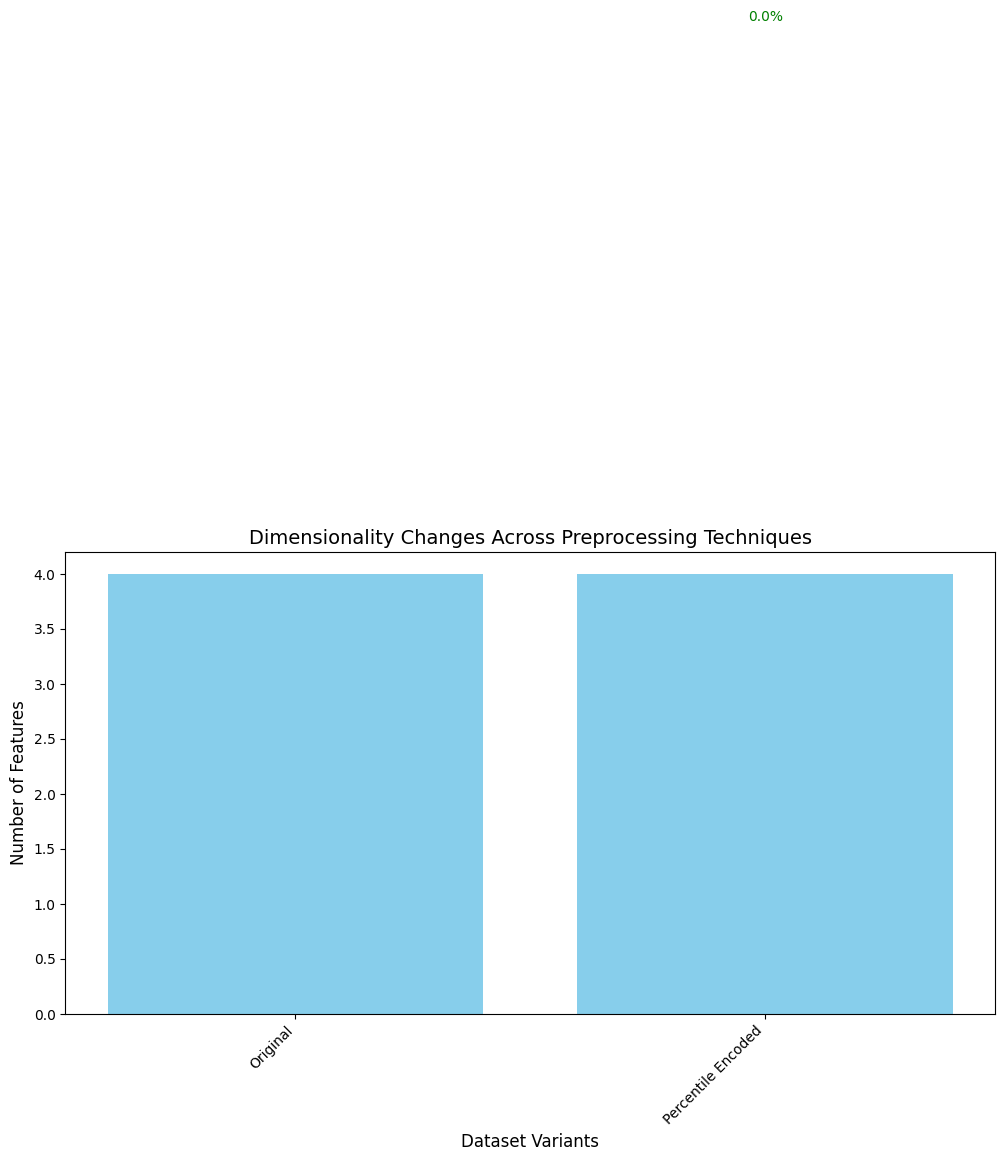

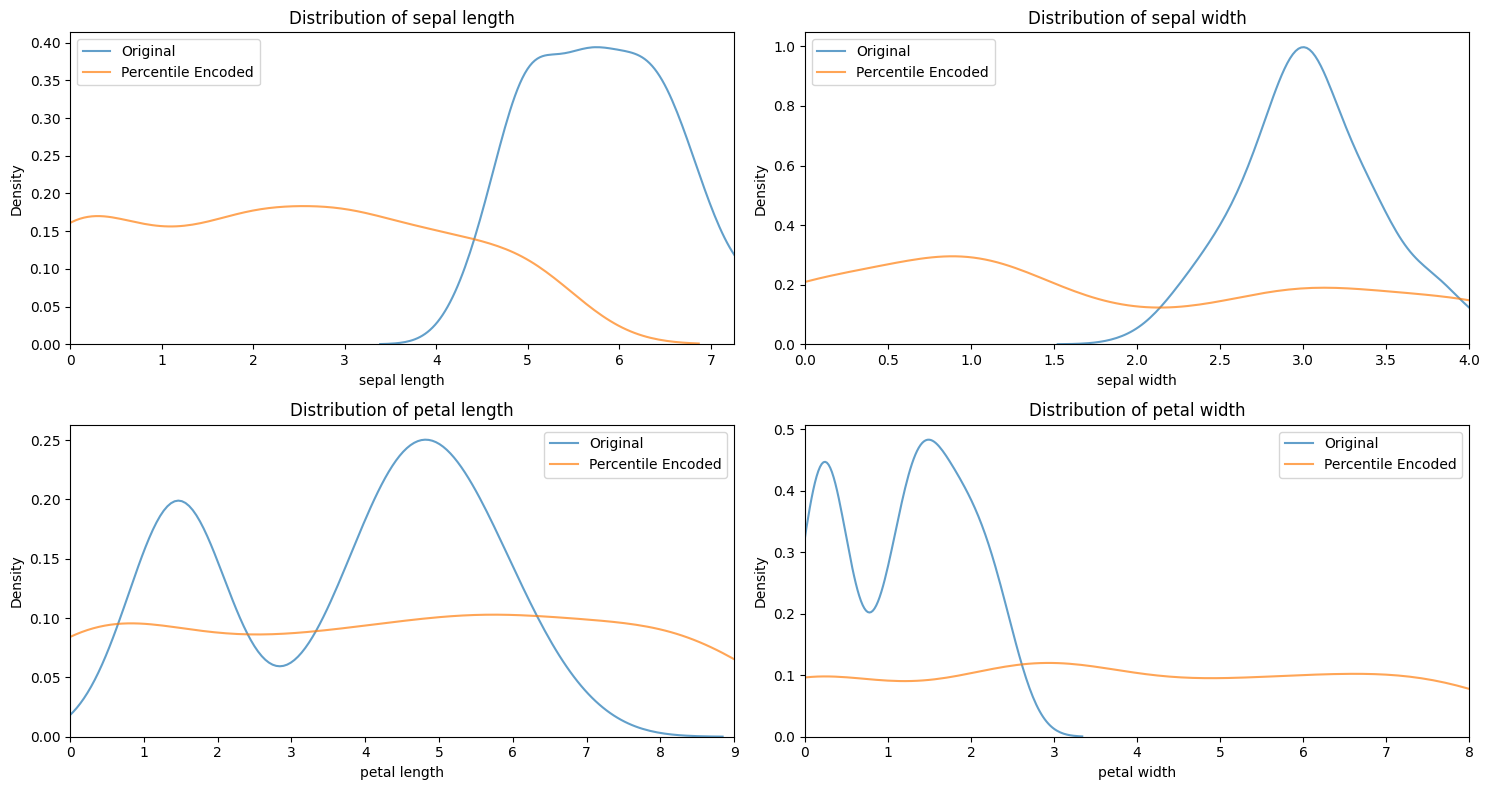

/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


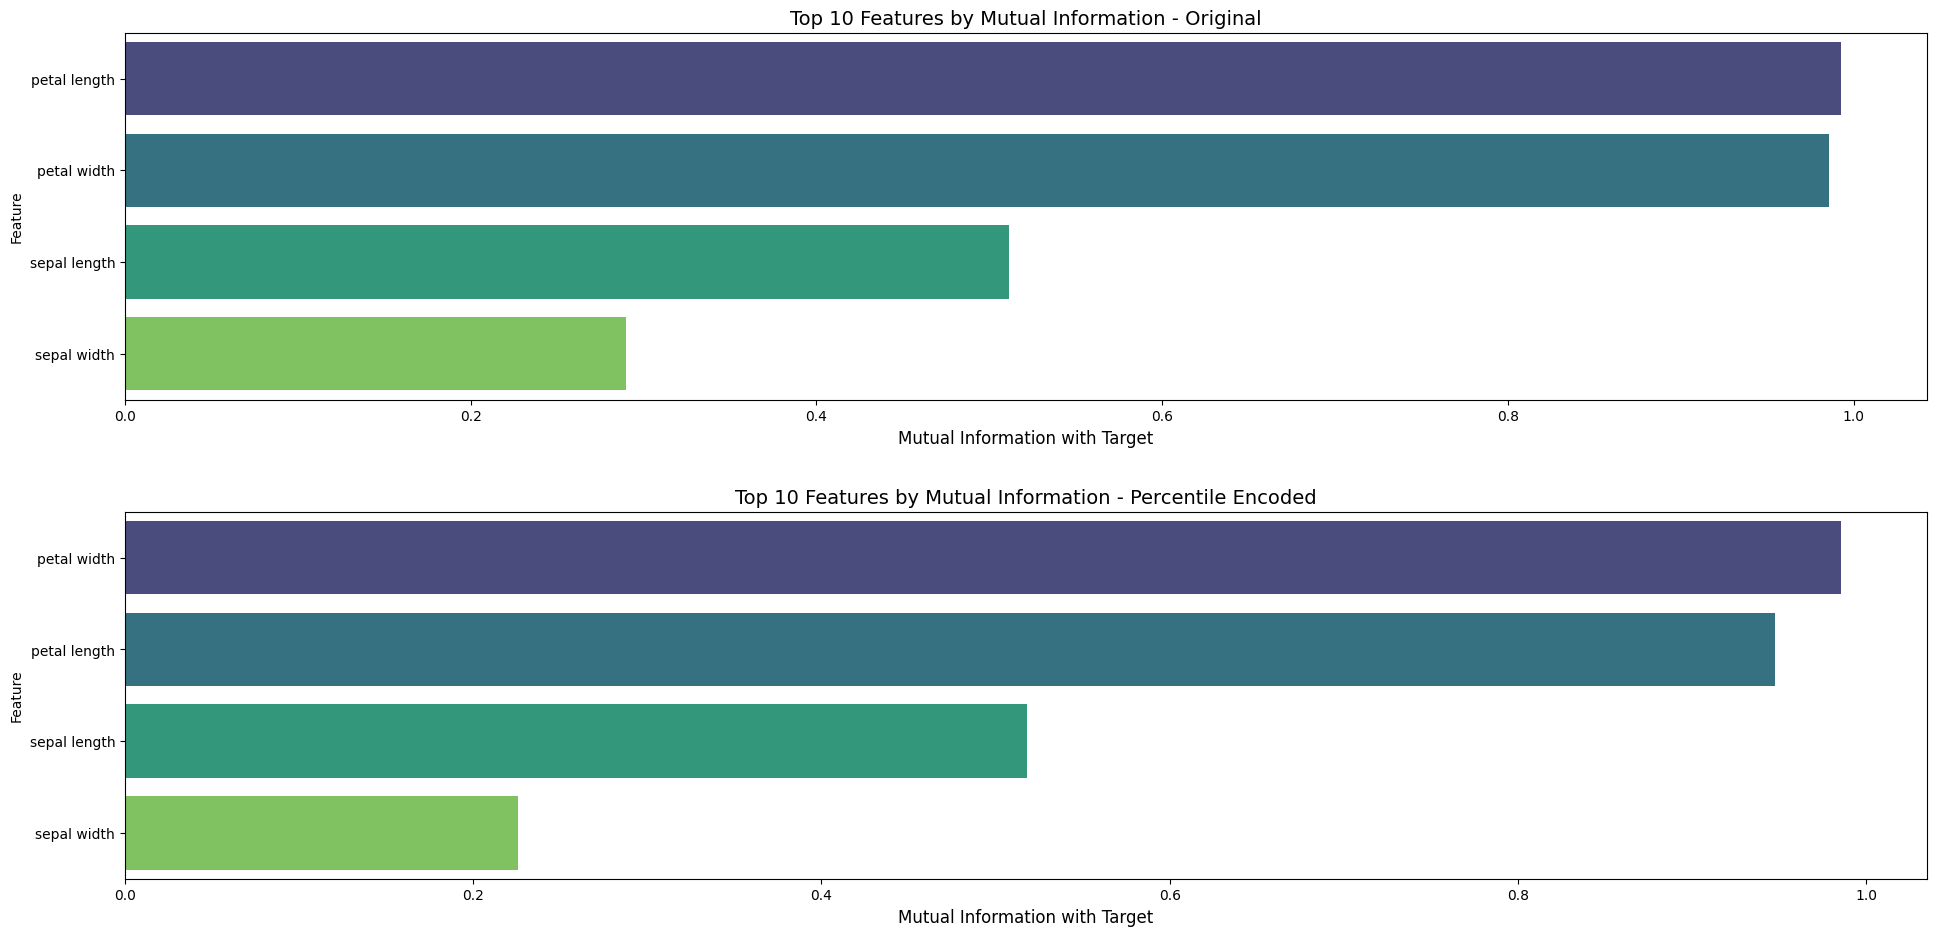


--- Iris Dataset Summary ---
Original: 150 samples, 4 features
   Memory usage: 0.00 MB
Percentile Encoded: 150 samples, 4 features
   Memory usage: 0.00 MB

===== Comparing Wine Dataset Variants =====


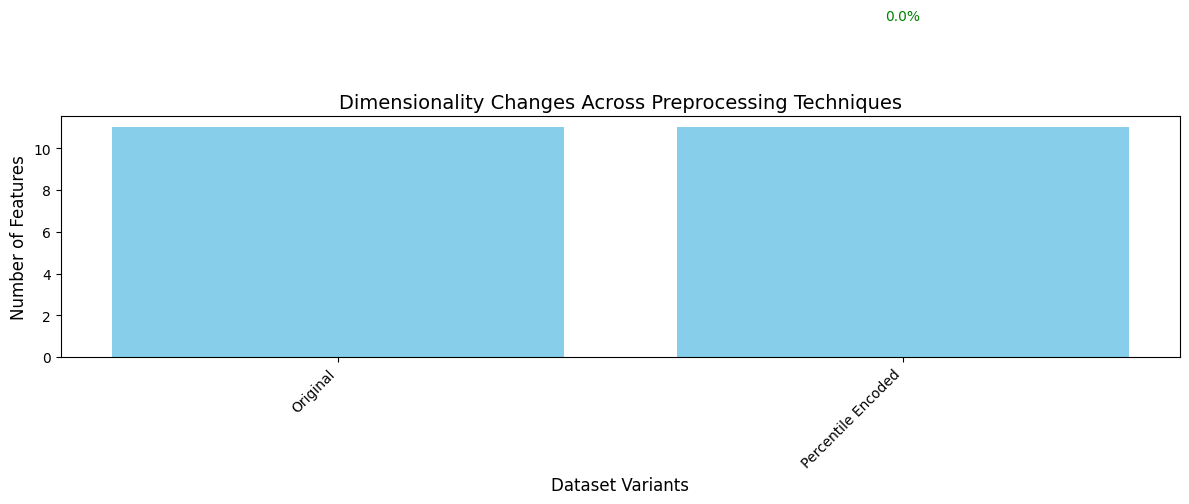

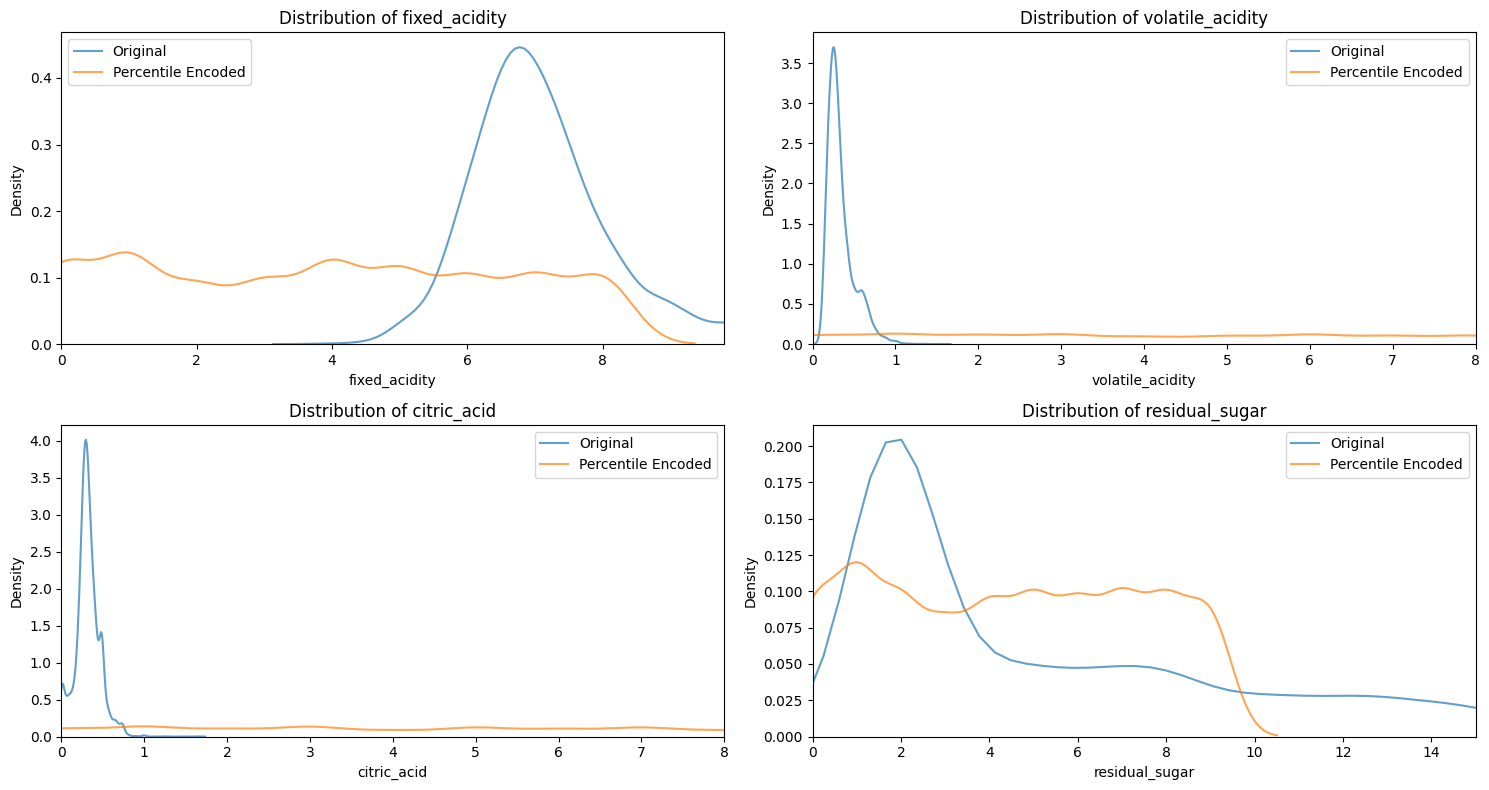

/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


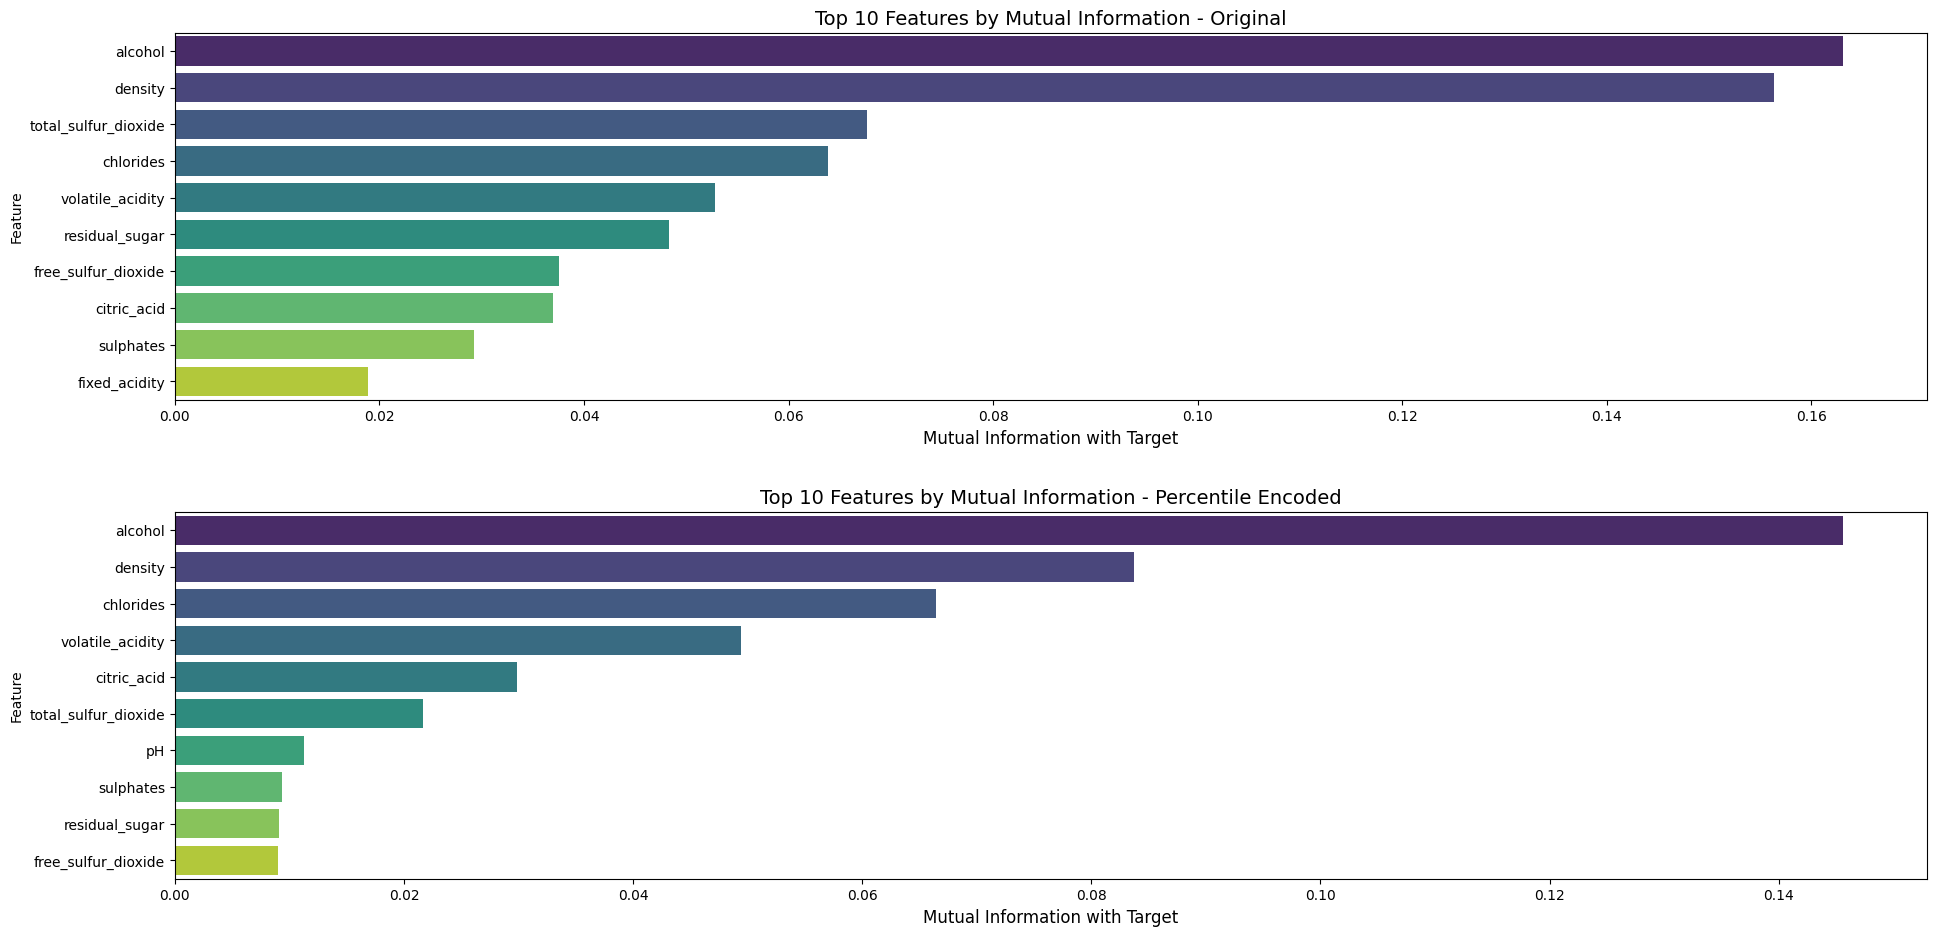


--- Wine Dataset Summary ---
Original: 6497 samples, 11 features
   Memory usage: 0.55 MB
Percentile Encoded: 6497 samples, 11 features
   Memory usage: 0.55 MB

===== Comparing Adult_Census Dataset Variants =====


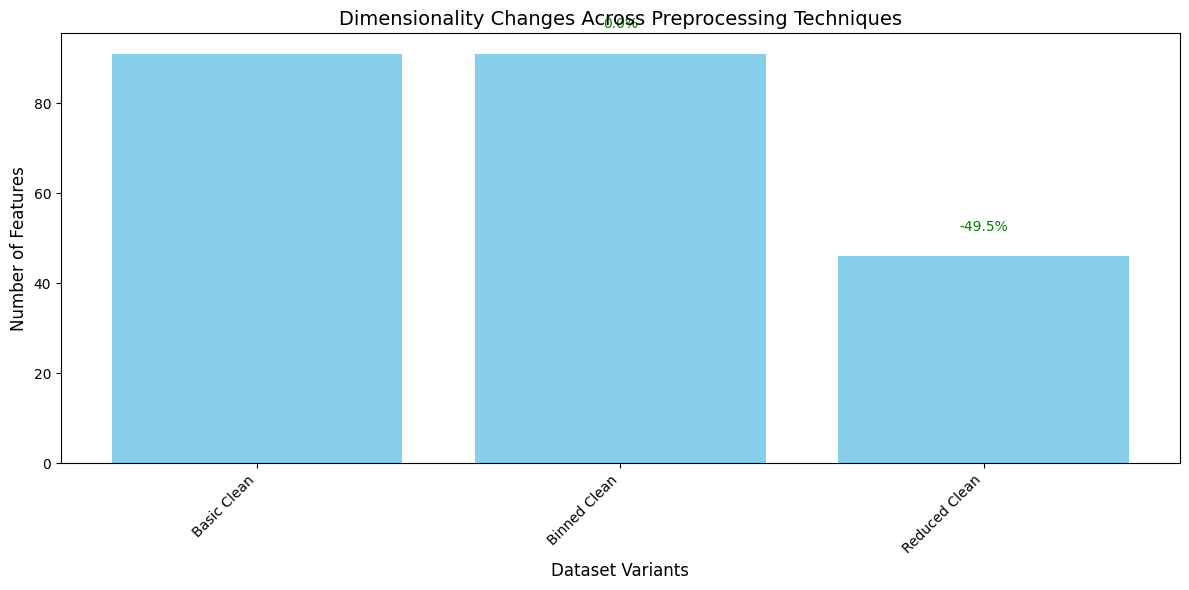

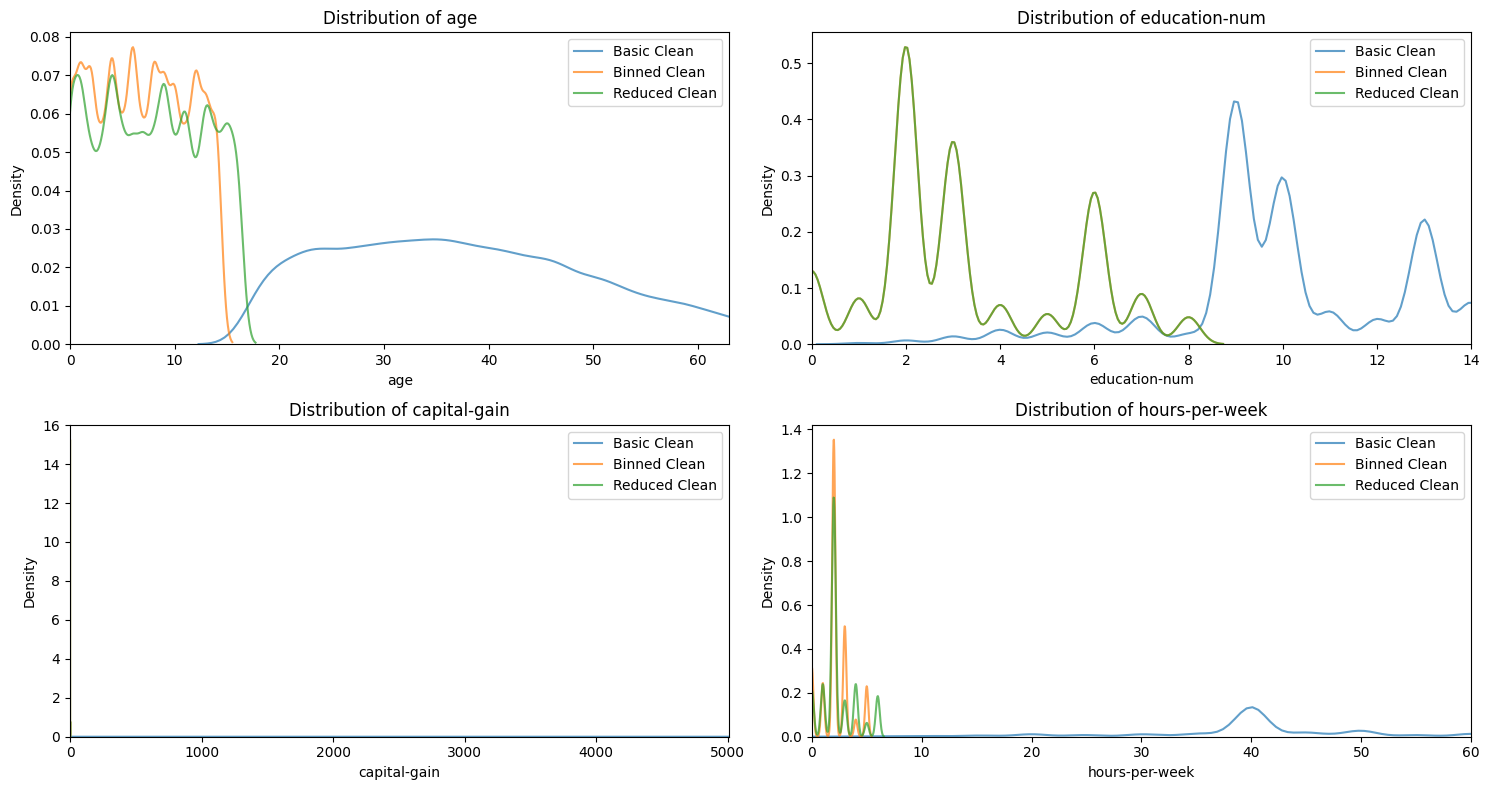

/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


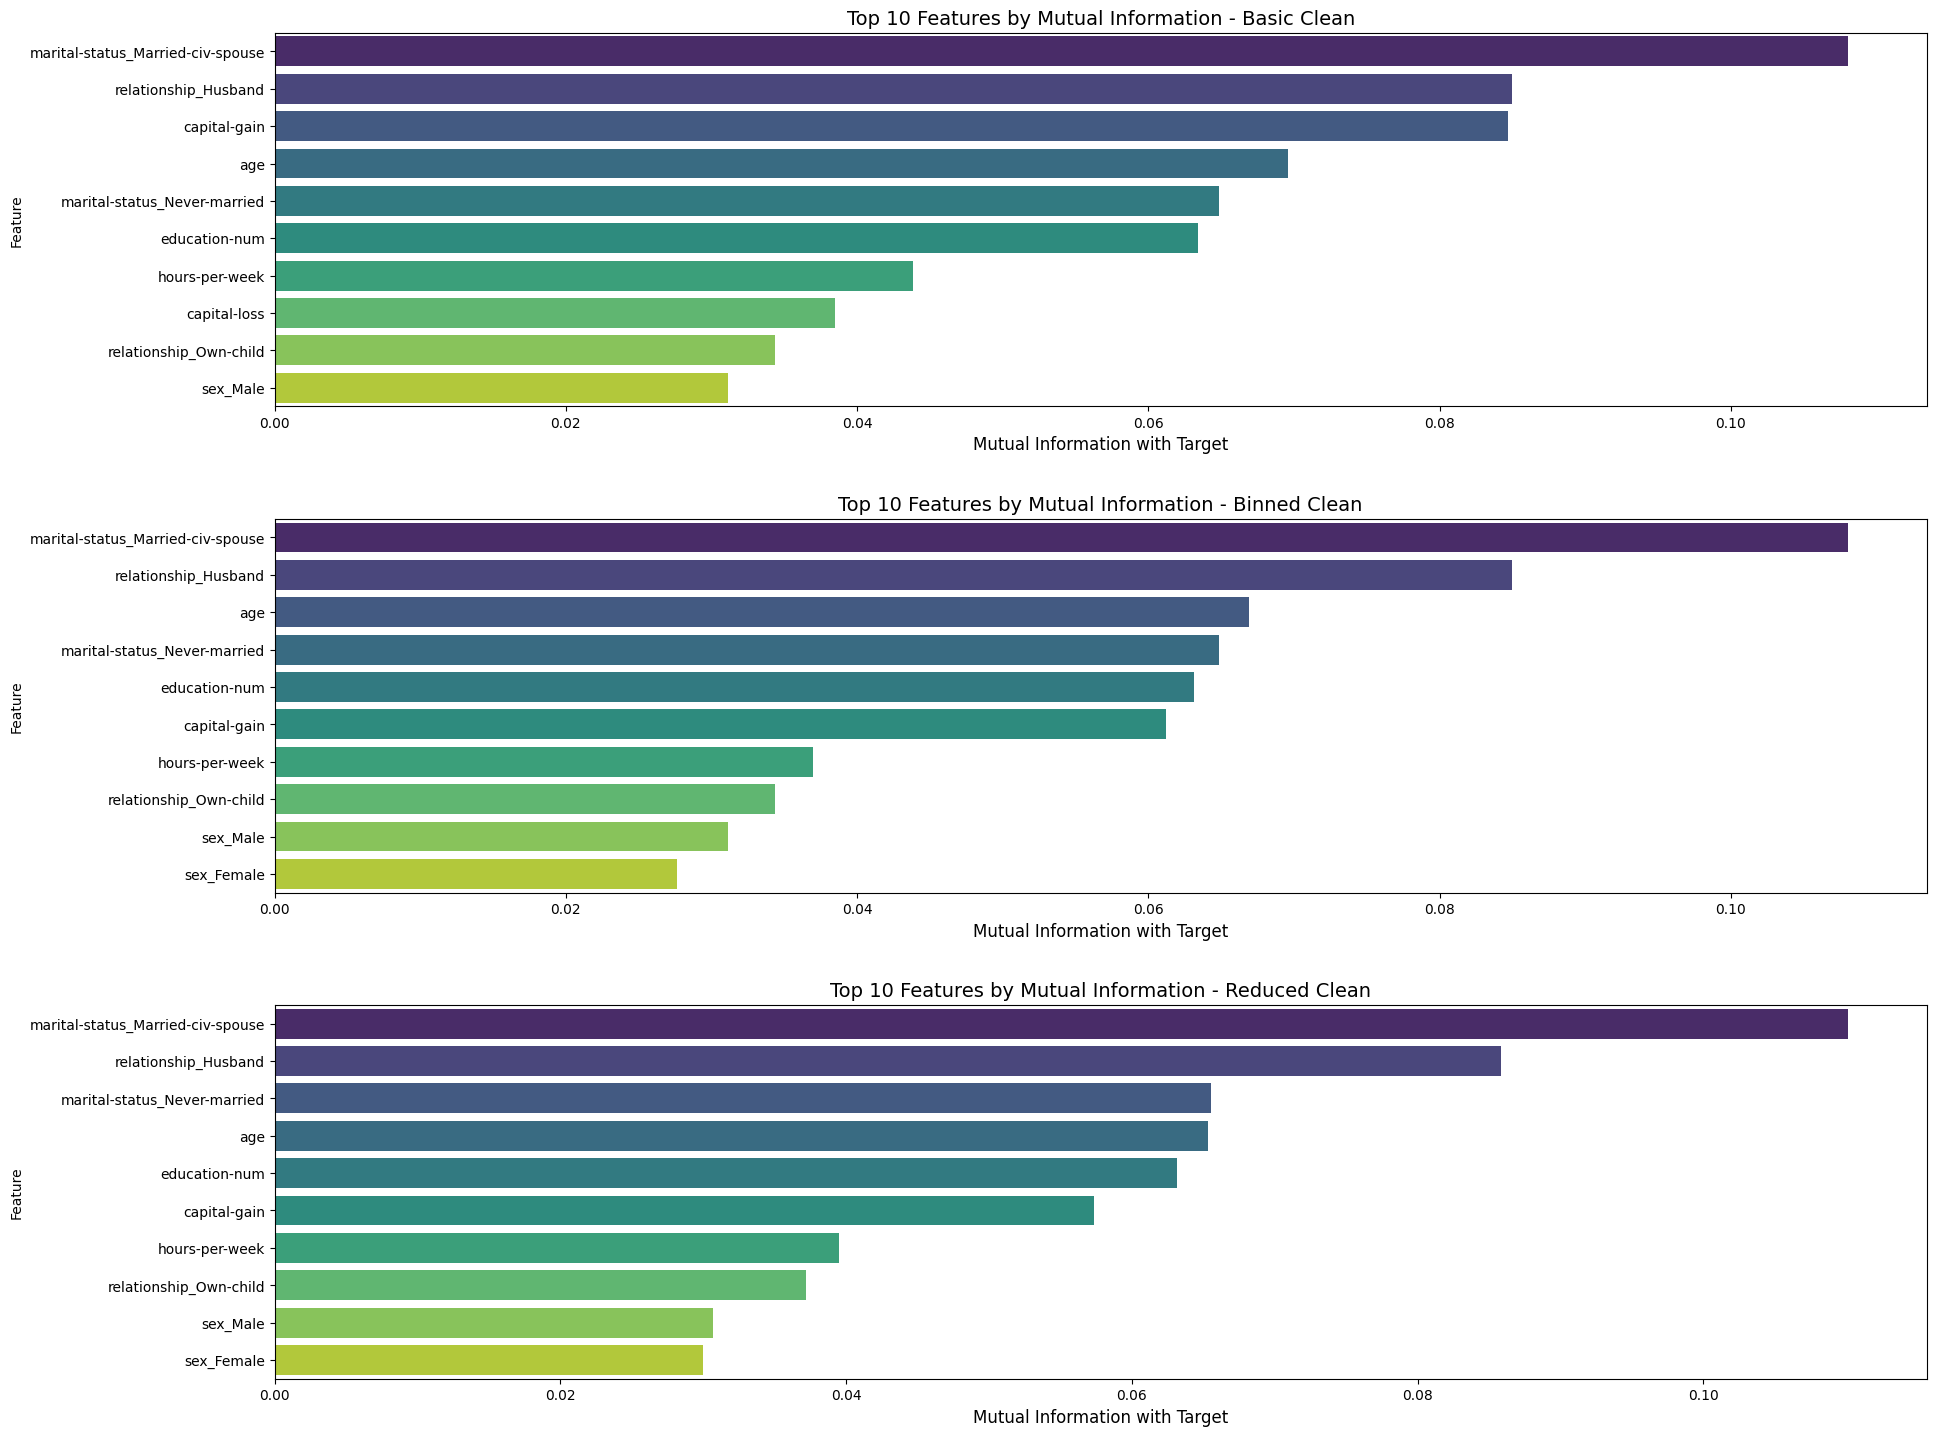


--- Adult_Census Dataset Summary ---
Basic Clean: 47621 samples, 91 features
   Memory usage: 33.43 MB
Binned Clean: 47621 samples, 91 features
   Memory usage: 33.43 MB
Reduced Clean: 47621 samples, 46 features
   Memory usage: 17.08 MB

===== Comparing Bank_Marketing Dataset Variants =====


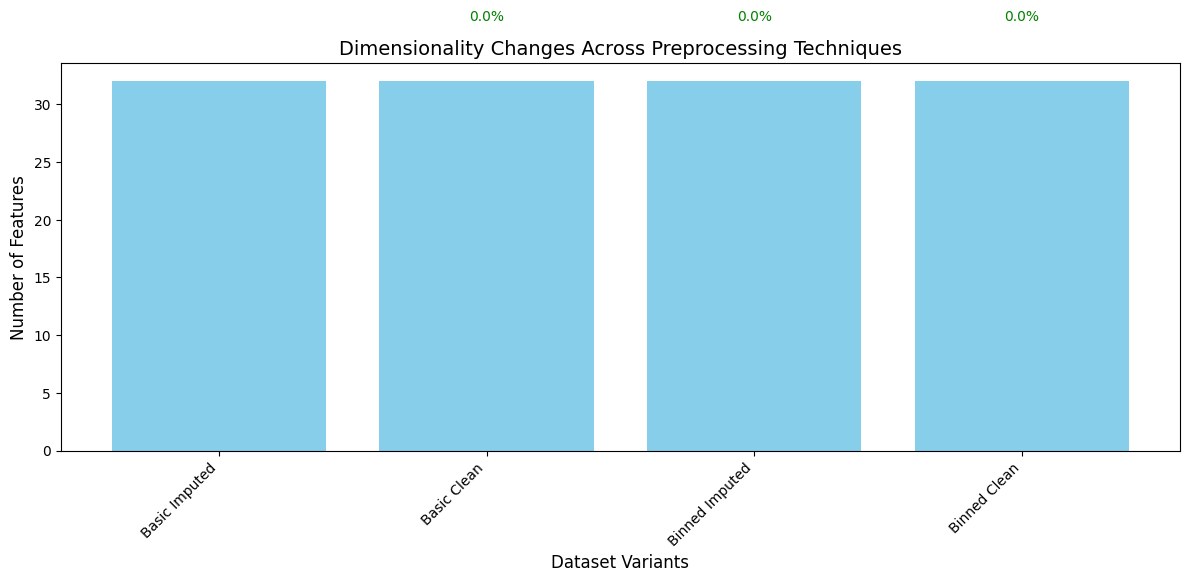

/tmp/ipykernel_78467/1255903858.py:167: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[feature], label=titles[i], alpha=0.7)
/tmp/ipykernel_78467/1255903858.py:167: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[feature], label=titles[i], alpha=0.7)


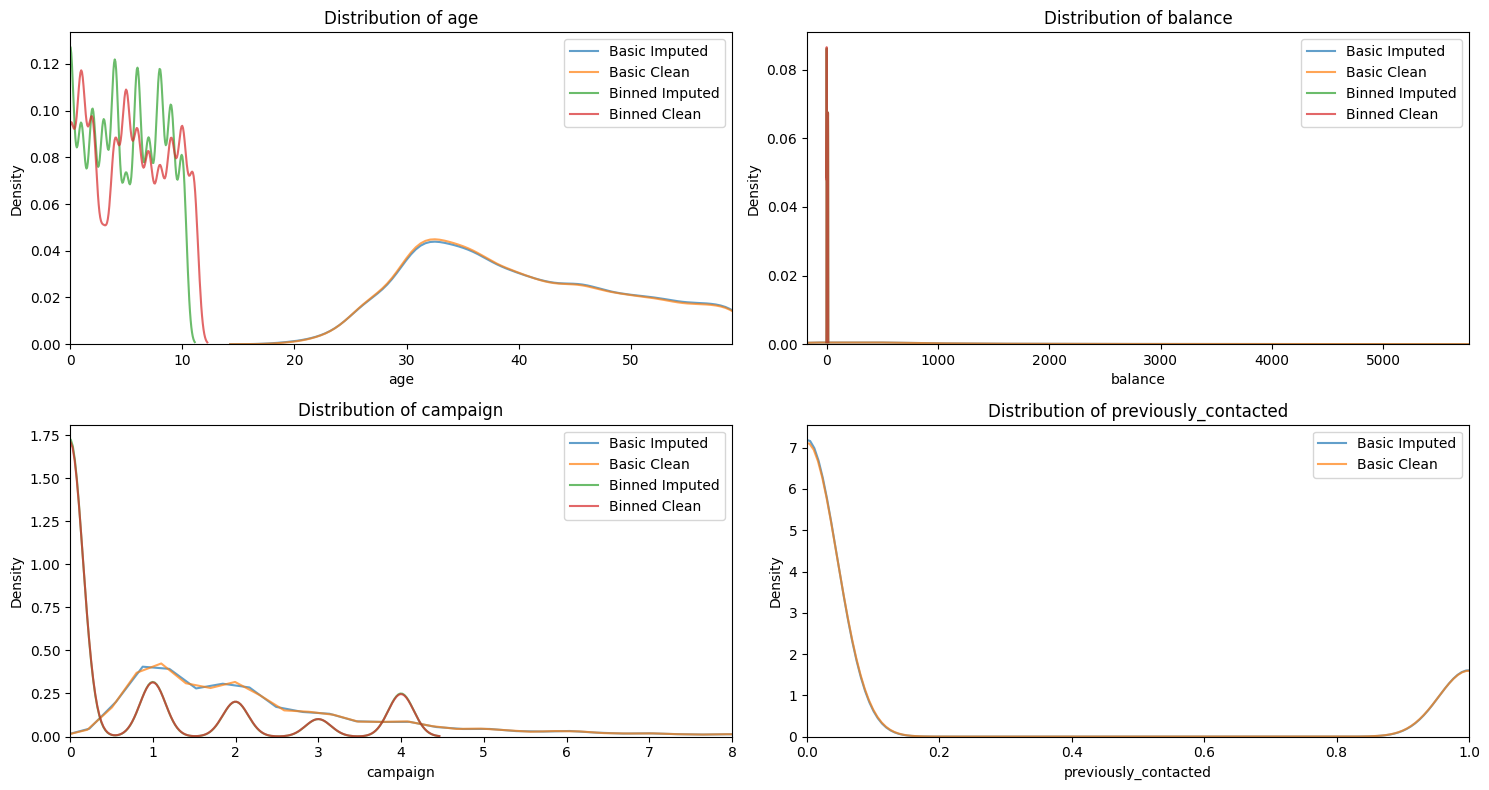

/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

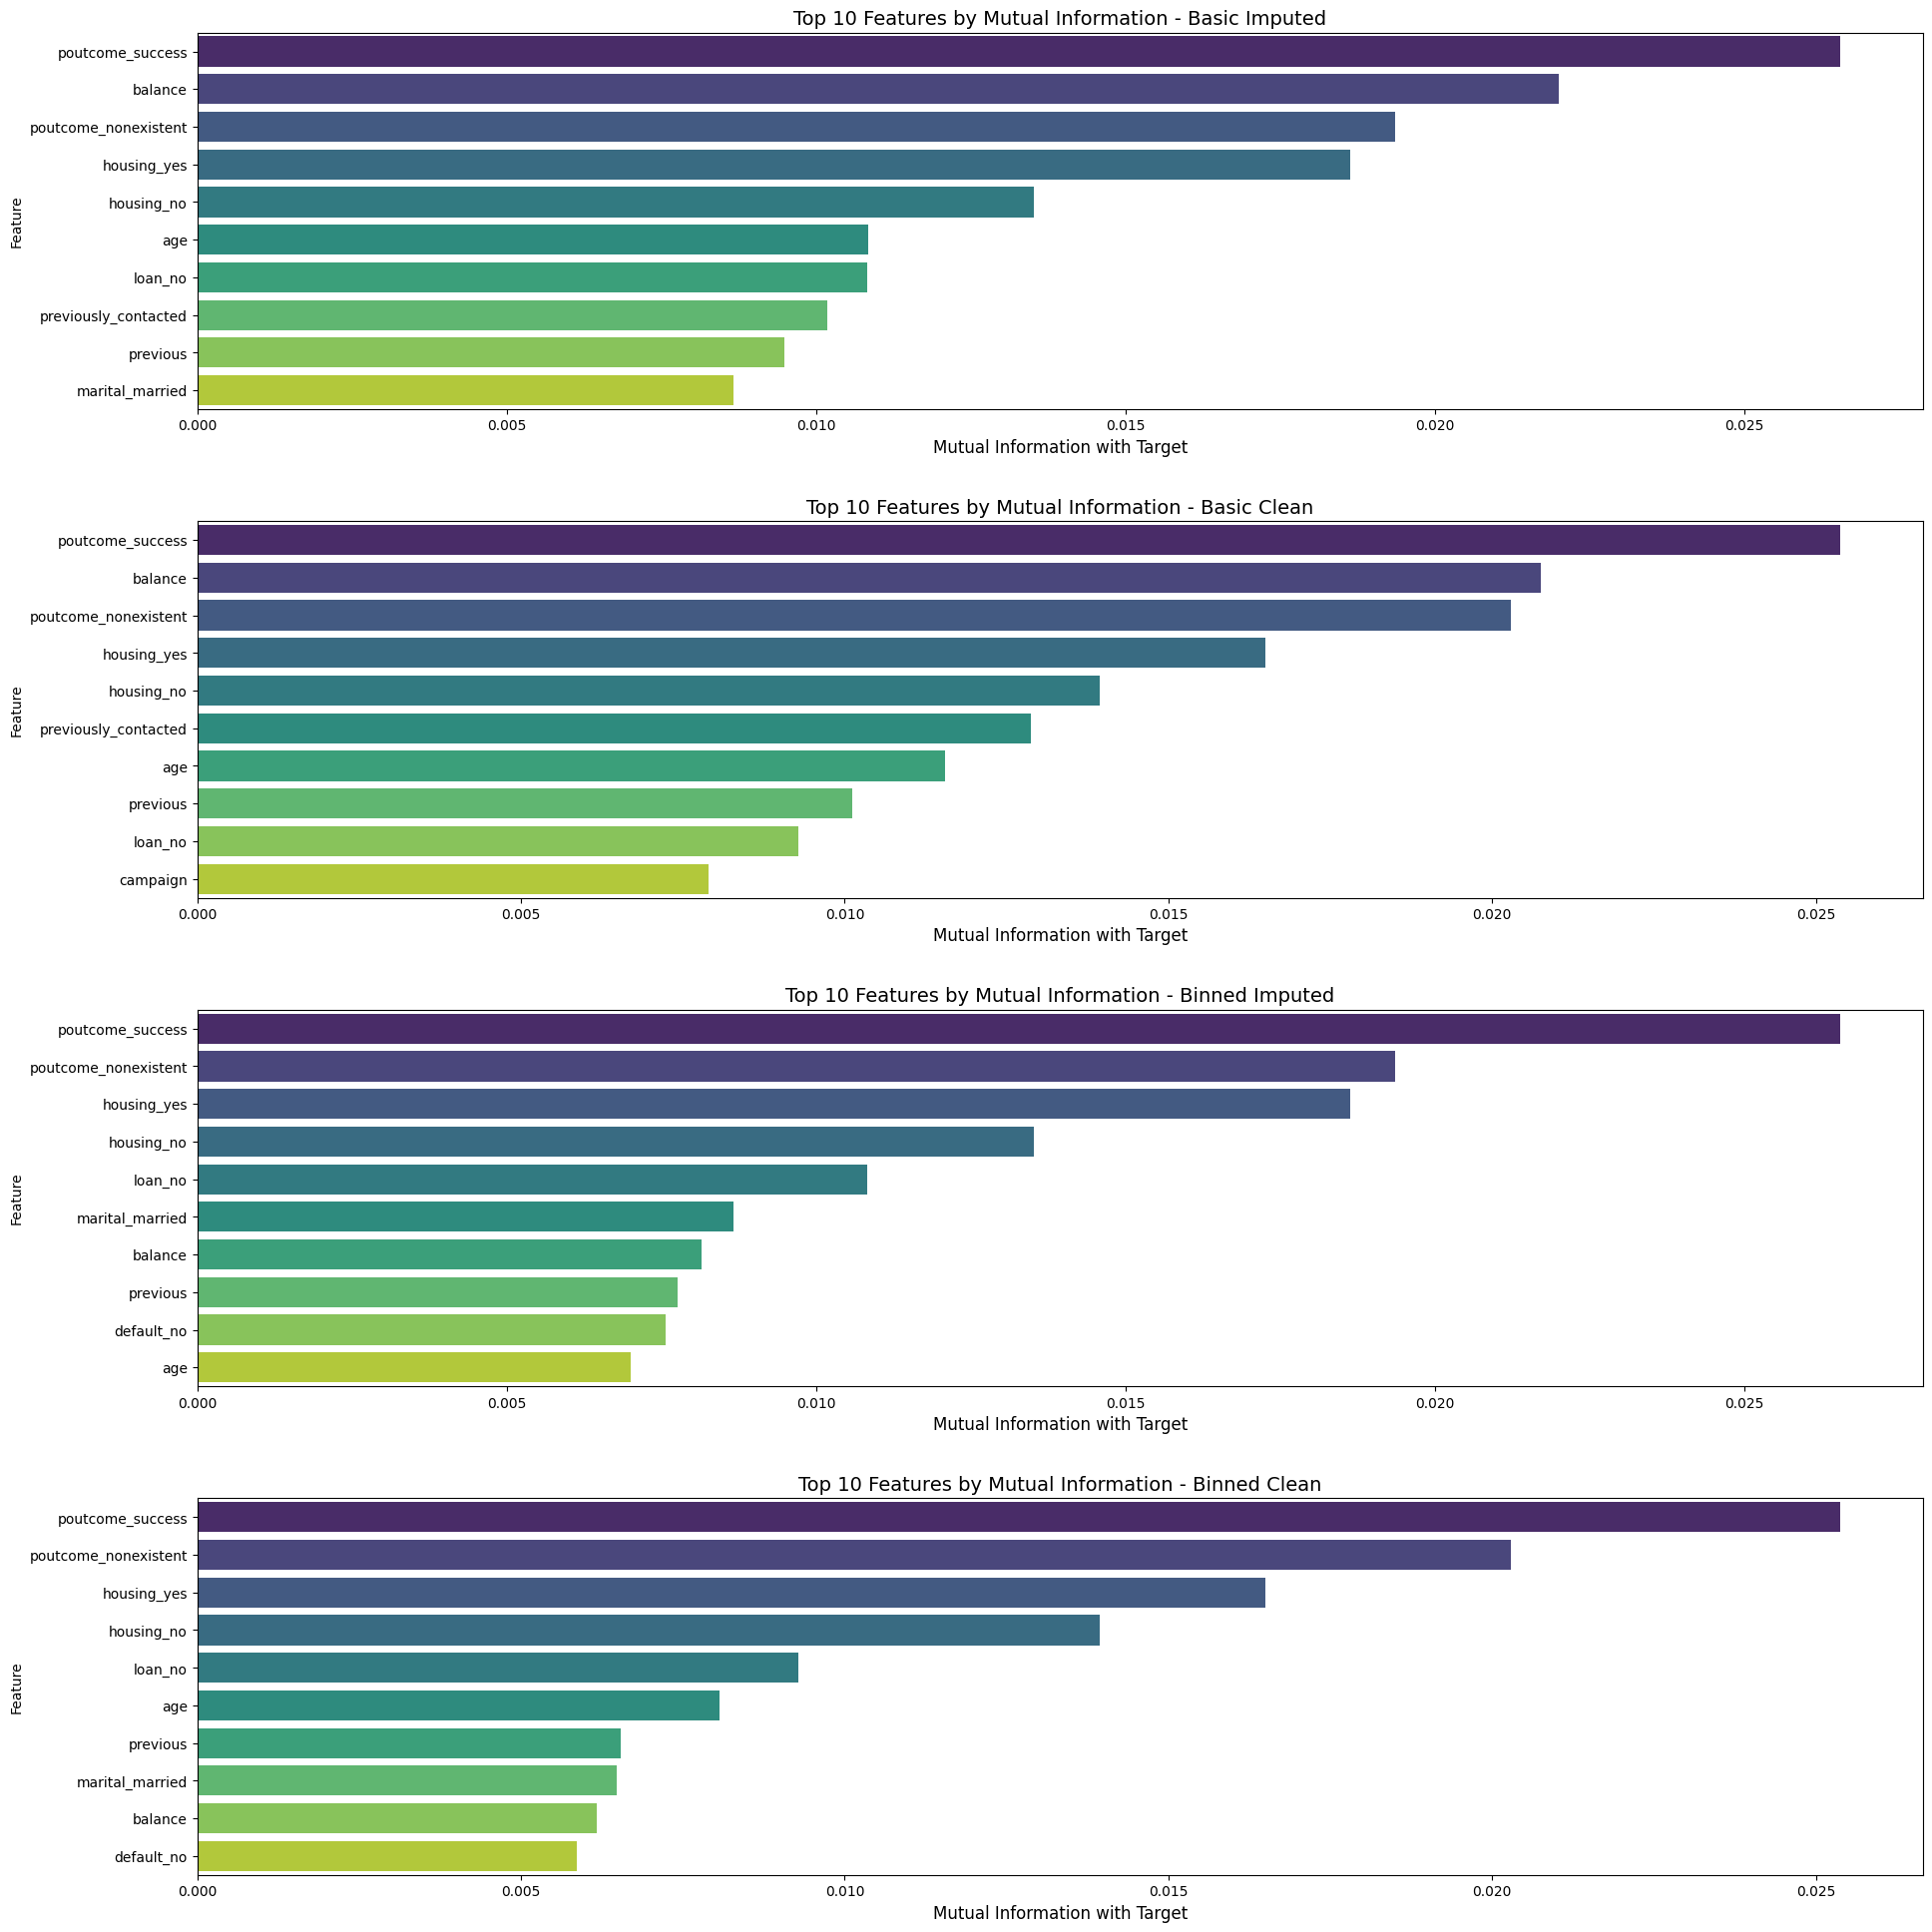


--- Bank_Marketing Dataset Summary ---
Basic Imputed: 45211 samples, 32 features
   Memory usage: 11.04 MB
Basic Clean: 43193 samples, 32 features
   Memory usage: 10.87 MB
Binned Imputed: 45211 samples, 32 features
   Memory usage: 11.04 MB
Binned Clean: 43193 samples, 32 features
   Memory usage: 10.87 MB

===== Comparing MNIST Dataset Variants =====


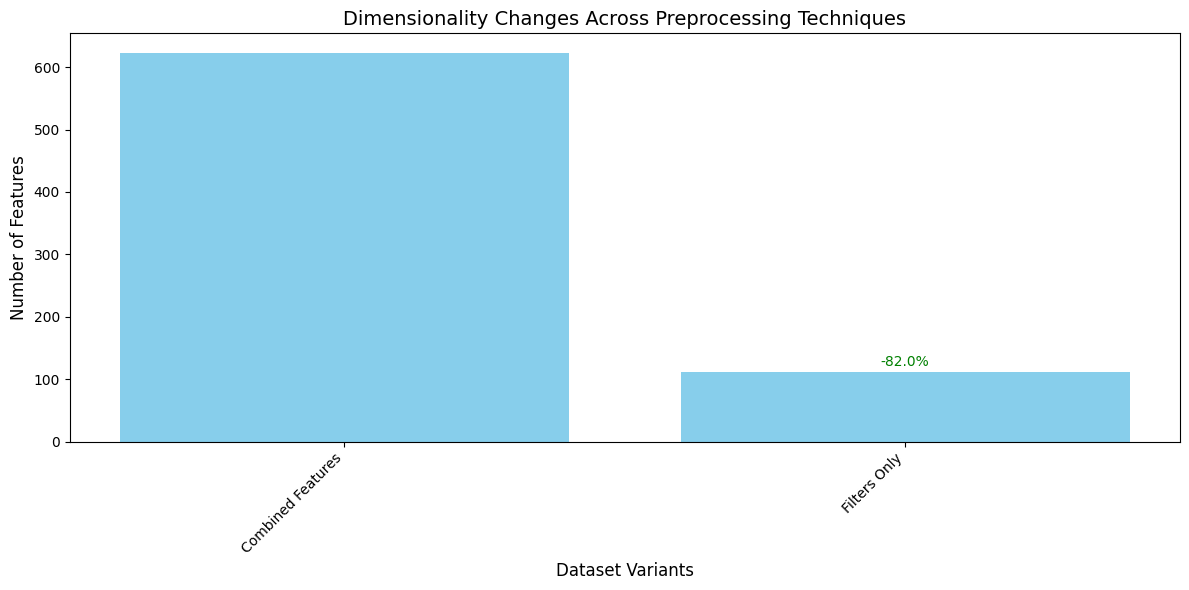

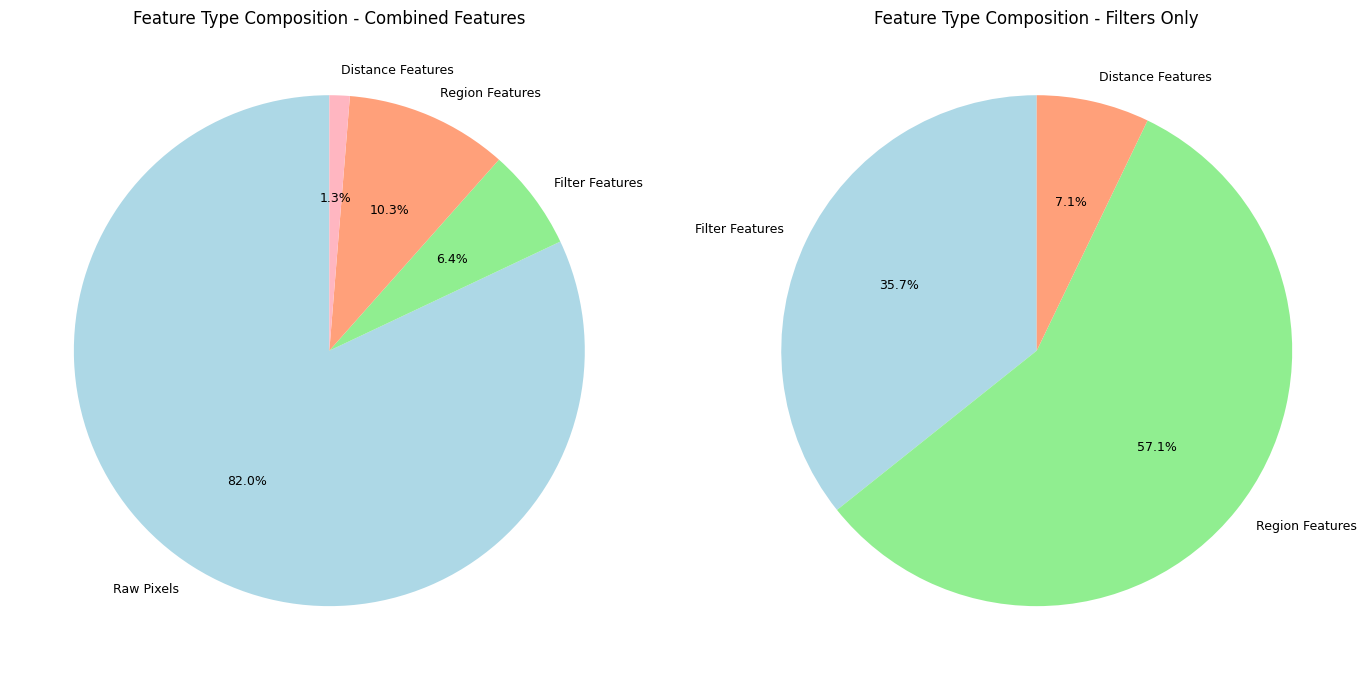

/tmp/ipykernel_78467/1255903858.py:167: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[feature], label=titles[i], alpha=0.7)
/tmp/ipykernel_78467/1255903858.py:167: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[feature], label=titles[i], alpha=0.7)
/tmp/ipykernel_78467/1255903858.py:170: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(feature_min, feature_max)
/tmp/ipykernel_78467/1255903858.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


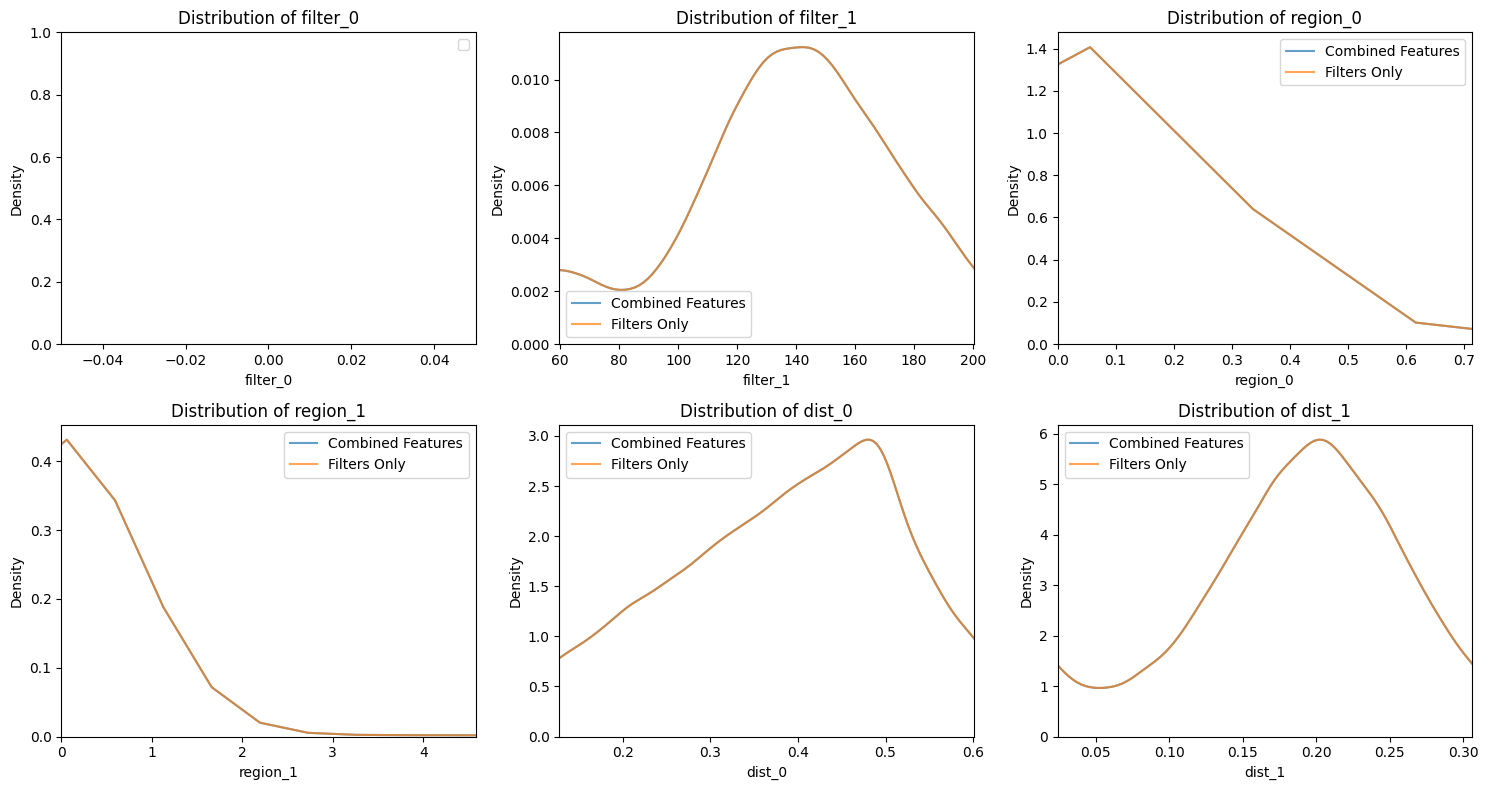

/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
/tmp/ipykernel_78467/1255903858.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


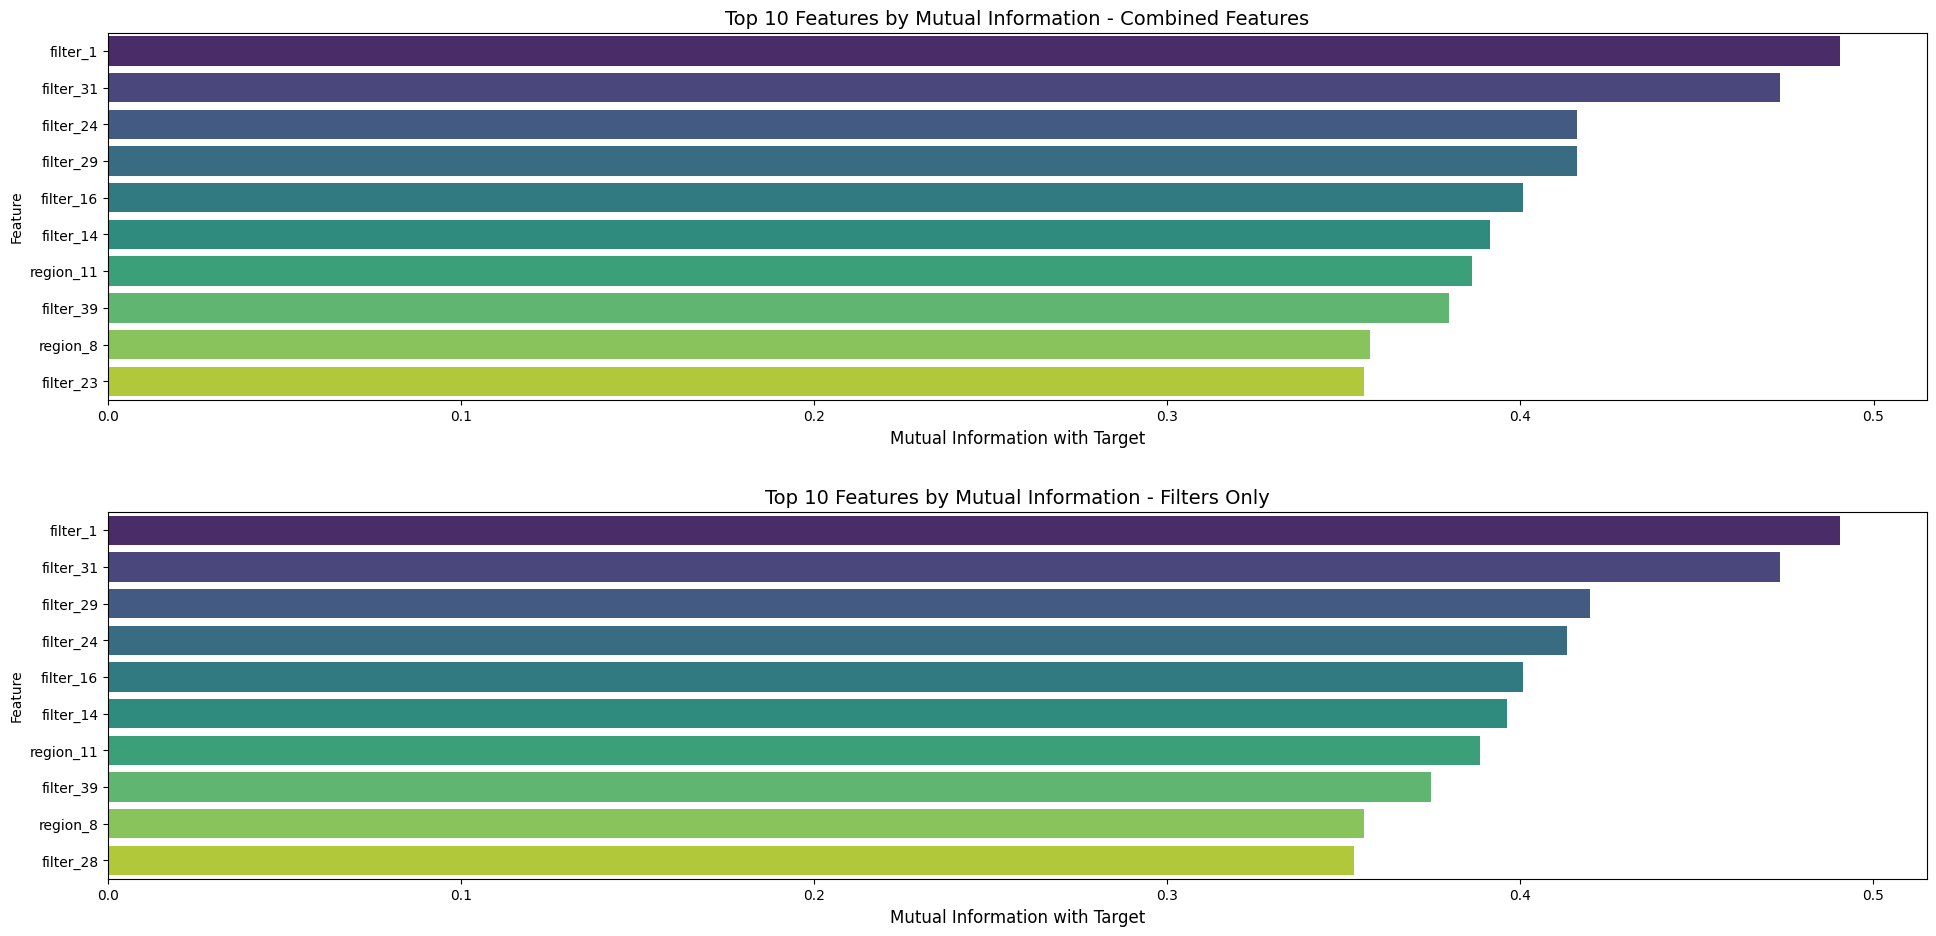


--- MNIST Dataset Summary ---
Combined Features: 70000 samples, 623 features
   Memory usage: 332.72 MB
   Feature composition: 511 pixels, 40 filter, 64 region, 8 distance
Filters Only: 70000 samples, 112 features
   Memory usage: 59.81 MB
   Feature composition: 0 pixels, 40 filter, 64 region, 8 distance


In [23]:
# Iris
compare_dataset_variants(
    datasets=[X_iris, X_iris_binned],
    y_values=[y_iris, y_iris],
    titles=['Original', 'Percentile Encoded'],
    dataset_name='Iris'
)

# Wine
compare_dataset_variants(
    datasets=[X_wine, X_wine_binned],
    y_values=[y_wine, y_wine],
    titles=['Original', 'Percentile Encoded'],
    dataset_name='Wine'
)

# Adult Census
compare_dataset_variants(
    datasets=[X_adult_basic_clean, X_adult_binned_clean, X_adult_reduced_clean],
    y_values=[y_adult_clean, y_adult_clean, y_adult_clean],
    titles=['Basic Clean', 'Binned Clean', 'Reduced Clean'],
    dataset_name='Adult_Census'
)

# Bank Marketing
compare_dataset_variants(
    datasets=[X_bank_basic_imputed, X_bank_basic_clean, X_bank_binned_imputed, X_bank_binned_clean],
    y_values=[y_bank, y_bank_clean, y_bank, y_bank_clean],
    titles=['Basic Imputed', 'Basic Clean', 'Binned Imputed', 'Binned Clean'],
    dataset_name='Bank_Marketing'
)

# MNIST
compare_dataset_variants(
    datasets=[X_final_mnist, X_filters_only],
    y_values=[y_mnist, y_mnist],
    titles=['Combined Features', 'Filters Only'],
    dataset_name='MNIST'
)